# Exploratory analysis of Australian electricity demand

This notebook explores the five half-hourly demand series selected in the [dataset
card](../docs/DATASET_CARD.md). It feeds the open questions on source semantics in issue
#6 and the split proposal in the [problem definition](../docs/problem-definition.md)
(#5, #17).

Most sections use only the proposed training block `[0, 195696)`. Section 9 also
compares the validation block with the last training year, since validation data can
inform model selection. Test targets are never loaded; the notebook uses test positions
only to work out dates. The split boundaries are still a team proposal.

The source file has one start string per series (`2002-01-01 00-00-00`) and no timestamp
per observation, so the analysis works on positions. Where a calendar helps, it uses a
nominal date that assumes contiguous 30-minute steps from that start string. Section 6
tests that assumption.

The data is the DVC-tracked copy in `data/raw/` (one Parquet file per state, written by
`src/dataset.py` in #16); run `uv run dvc pull` first. The source labels Queensland `QUN`;
the versioned data and this notebook call it `QLD`. Section 1.1 traces the values to AEMO operational demand excluding large industrial
loads; the unit is not stated in the files and is most likely MW.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIGURES_DIR, RAW_DATA_DIR

# DVC-tracked series from #16 (data/raw.dvc); restore them with `uv run dvc pull`.

STEPS_PER_DAY = 48
STEPS_PER_WEEK = 7 * STEPS_PER_DAY
COMMON_LENGTH = 230_736  # proposed common prefix for all states
TRAIN_END = 195_696  # proposed end of the training block (exclusive)
NOMINAL_START = pd.Timestamp("2002-01-01 00:00")  # start string of every source record

# Fixed state order and colours (validated categorical palette, slots 1-5).
STATES = ["NSW", "VIC", "QLD", "SA", "TAS"]
COLORS = dict(zip(STATES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "lines.linewidth": 1.5,
})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"eda_{name}.png", bbox_inches="tight")

2026-10-02 22:31:38.291 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /home/linux/Documentos/MASTER_DATASCIENCE/3R_SEMESTRE/MLOps/Project/MLOps_Endesa


## 1. Load and verify the versioned data

Each Parquet file holds one state's series, named by its column, on a positional
`timestep` index. The values are stored as `float32`, so they differ from the source text
by less than 0.001. The check below compares each file with the counts and ranges that
the [dataset card](../docs/DATASET_CARD.md) recorded from the pinned archive. A state
mapped to the wrong record would fail it, since the five ranges do not overlap at both ends.

In [2]:
# Observations, minimum, maximum and negatives recorded in the dataset card.
CARD = {
    "NSW": (230_736, 3_498.38527, 12_865.79582, 0),
    "VIC": (230_736, 2_688.51661, 9_494.01099, 0),
    "QLD": (232_272, 2_008.62345, 7_514.43652, 0),
    "SA": (230_784, 488.83538, 3_182.47665, 0),
    "TAS": (230_736, -233.90682, 1_093.50213, 22),
}

raw = {}
for state in STATES:
    frame = pd.read_parquet(RAW_DATA_DIR / f"{state}.parquet")
    assert list(frame.columns) == [state], frame.columns
    raw[state] = frame[state].to_numpy(dtype=np.float64)

checks = pd.DataFrame({
    state: {
        "observations": len(v),
        "beyond common prefix": len(v) - COMMON_LENGTH,
        "min": v.min(),
        "max": v.max(),
        "negative": int((v < 0).sum()),
        "matches card": (len(v), int((v < 0).sum())) == (CARD[state][0], CARD[state][3])
        and np.allclose([v.min(), v.max()], CARD[state][1:3], atol=1e-3),
    }
    for state, v in raw.items()
}).T
assert checks["matches card"].all(), checks
checks

,observations,beyond common prefix,min,max,negative,matches card
NSW,230736,0,3498.385254,12865.795898,0,True
VIC,230736,0,2688.516602,9494.010742,0,True
QLD,232272,1536,2008.623413,7514.436523,0,True
SA,230784,48,488.835388,3182.476562,0,True
TAS,230736,0,-233.906815,1093.502075,22,True


All five files match the card. The source lists its records as `T1 NSW, T2 VIC, T3 QUN,
T4 SA, T5 TAS`; the loader in `src/dataset.py` follows that order, and this check would
catch a mismatch.

### 1.1 Upstream AEMO files

The Zenodo record names the R package `tsibbledata` as the source. Its history keeps the
half-hourly AEMO files behind the former `aus_elec` dataset
([`data-raw/aus_elec`](https://github.com/tidyverts/tsibbledata/tree/58ea72462a4b34c4d50c2223b217a891a3d9416c/data-raw/aus_elec)
at commit `58ea724`), one `demand.csv` per state with the columns `Date` (spreadsheet
serial day), `Period` (1-48), `OperationalLessIndustrial` and `Industrial`. The package's
[preparation script](https://github.com/tidyverts/tsibbledata/blob/58ea72462a4b34c4d50c2223b217a891a3d9416c/data-raw/aus_elec/aus_elec.R)
takes `OperationalLessIndustrial` as demand. The cell downloads the five files from that
commit into `data/external/` (ignored by Git) and compares them with the DVC series.

In [3]:
import urllib.request

UPSTREAM_COMMIT = "58ea72462a4b34c4d50c2223b217a891a3d9416c"
UPSTREAM_URL = (
    "https://raw.githubusercontent.com/tidyverts/tsibbledata/"
    f"{UPSTREAM_COMMIT}/data-raw/aus_elec/{{state}}2015/demand.csv"
)
UPSTREAM_DIR = RAW_DATA_DIR.parent / "external" / "aus_elec"
UPSTREAM_DIR.mkdir(parents=True, exist_ok=True)

upstream = {}
for state in STATES:
    path = UPSTREAM_DIR / f"{state}_demand.csv"
    if not path.exists():
        urllib.request.urlretrieve(UPSTREAM_URL.format(state=state), path)
    frame = pd.read_csv(path)
    frame["day"] = pd.Timestamp("1899-12-30") + pd.to_timedelta(frame["Date"], unit="D")
    upstream[state] = frame

provenance = pd.DataFrame({
    state: {
        "upstream rows": len(u),
        "first day": u["day"].min().date(),
        "last day": u["day"].max().date(),
        "days without 48 periods": int((u.groupby("Date").size() != STEPS_PER_DAY).sum()),
        "duplicate (day, period)": int(u.duplicated(["Date", "Period"]).sum()),
        "DVC rows": len(raw[state]),
        "max |DVC - OperationalLessIndustrial|": np.abs(
            raw[state] - u["OperationalLessIndustrial"].to_numpy()[: len(raw[state])]
        ).max(),
        "mean OperationalLessIndustrial": u["OperationalLessIndustrial"].mean(),
        "mean Industrial": u["Industrial"].mean(),
    }
    for state, u in upstream.items()
}).T
provenance

,upstream rows,first day,last day,days without 48 periods,"duplicate (day, period)",DVC rows,max |DVC - OperationalLessIndustrial|,mean OperationalLessIndustrial,mean Industrial
NSW,230784,2002-01-01,2015-03-01,0,0,230736,0.000488,6740.515589,1816.571853
VIC,230784,2002-01-01,2015-03-01,0,0,230736,0.000485,4638.96296,1133.089038
QLD,232272,2002-01-01,2015-04-01,0,0,232272,0.000244,4319.357468,1439.126606
SA,230784,2002-01-01,2015-03-01,0,0,230784,0.000122,1290.592171,279.572775
TAS,230784,2002-01-01,2015-03-01,0,0,230736,0.000061,507.200595,667.258007


Every DVC series equals the first rows of `OperationalLessIndustrial`, up to the
`float32` rounding of the Parquet files. Monash dropped the last upstream day
(2015-03-01) for NSW, VIC and TAS and kept it for SA, which explains SA's 48 extra steps.
QLD runs to 2015-04-01 in both. The upstream files have no duplicate rows and exactly 48
periods on every day, so they contain no 46- or 50-period DST transition days.

The series is therefore AEMO operational demand minus the separately reported industrial
load, which is large: in TAS the mean industrial load (about 670) is higher than the mean
series value. Neither file states a unit; AEMO reports operational demand in MW, so MW is
the likely unit. This is a secondary source (a package's raw files), not AEMO's own
documentation.

In [4]:
train = pd.DataFrame({state: raw[state][:TRAIN_END] for state in STATES})
train.index.name = "position"
nominal_time = NOMINAL_START + pd.to_timedelta(train.index * 30, unit="min")
n_days = TRAIN_END // STEPS_PER_DAY
nominal_days = pd.date_range(NOMINAL_START, periods=n_days, freq="D")
print(f"training block: {TRAIN_END:,} steps = {n_days:,} nominal days "
      f"({nominal_days[0].date()} to {nominal_days[-1].date()})")

training block: 195,696 steps = 4,077 nominal days (2002-01-01 to 2013-02-28)


## 2. Distribution per state

In [5]:
summary = train.describe(percentiles=[0.01, 0.5, 0.99]).T
summary["negative"] = (train < 0).sum()
summary["zero"] = (train == 0).sum()
summary["max identical run"] = [
    int(np.max(np.diff(np.flatnonzero(np.diff(np.r_[0, (np.diff(train[s]) == 0), 0])))[::2], initial=0))
    for s in STATES
]
summary.round(1)

,count,mean,std,min,1%,50%,99%,max,negative,zero,max identical run
NSW,195696.0,6819.1,1376.8,3498.4,4163.6,6889.8,10121.1,12865.8,0,0,0
VIC,195696.0,4642.2,830.6,2688.5,3163.0,4570.0,6707.6,9494.0,0,0,1
QLD,195696.0,4346.1,886.2,2008.6,2704.5,4410.3,6377.0,7514.4,0,0,0
SA,195696.0,1308.4,298.6,696.2,819.2,1297.4,2232.4,3182.5,0,0,0
TAS,195696.0,513.9,149.1,-233.9,267.3,497.0,903.1,1093.5,22,0,1


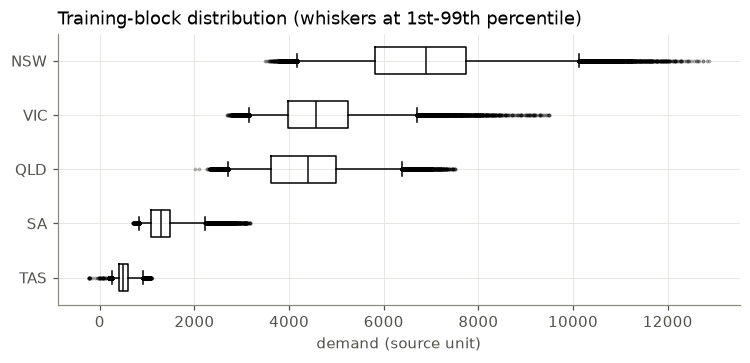

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.boxplot([train[s] for s in STATES], orientation="horizontal", whis=(1, 99), widths=0.5,
           flierprops={"markersize": 1.5, "alpha": 0.3},
           medianprops={"color": "#0b0b0b"}, tick_labels=STATES)
ax.invert_yaxis()
ax.set_xlabel("demand (source unit)")
ax.set_title("Training-block distribution (whiskers at 1st-99th percentile)", loc="left")
save(fig, "distribution")
plt.show()

Levels differ by more than an order of magnitude: the NSW mean is about 6,800 and the
TAS mean about 500. Absolute errors cannot be compared across states, which is why the
proposal uses a scaled metric such as MASE. There are no zeros and no runs of repeated
values, so nothing suggests that gaps were filled with constants.

## 3. Long-term level

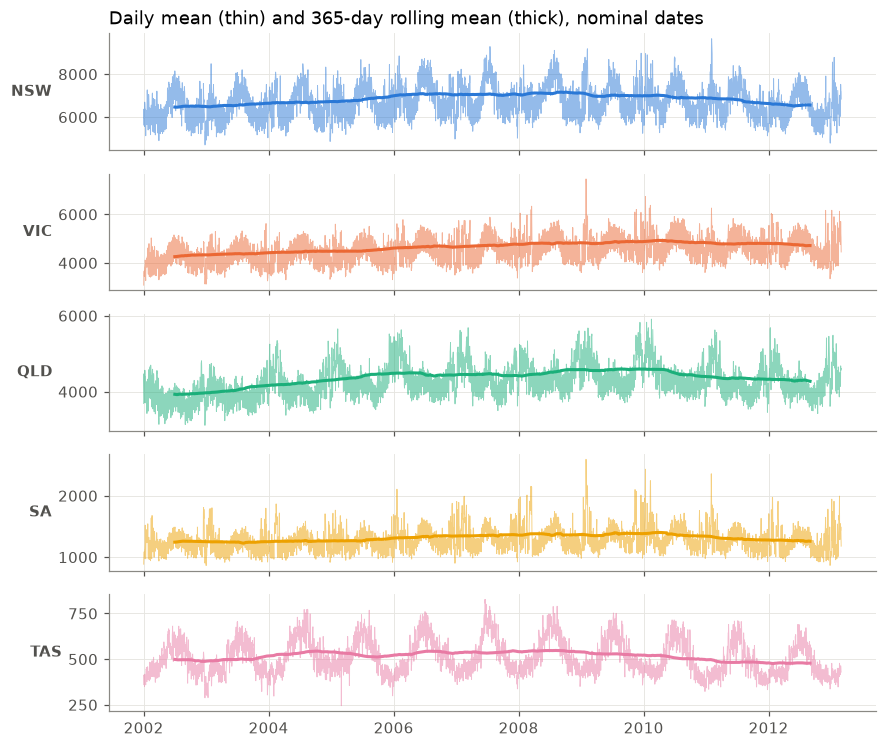

,year 1,year 2,year 3,year 4,year 5,year 6,year 7,year 8,year 9,year 10,year 11
NSW,100.0,101.3,103.5,105.3,109.3,109.2,109.9,108.5,106.9,105.4,101.2
VIC,100.0,102.9,104.5,105.5,109.5,110.8,112.9,113.9,114.8,112.4,111.4
QLD,100.0,102.9,107.6,112.1,113.3,113.6,114.7,116.6,114.3,110.7,109.3
SA,100.0,100.0,101.4,101.8,107.2,108.8,109.8,111.0,110.0,104.3,102.1
TAS,100.0,99.9,107.0,104.0,108.8,106.9,109.8,106.1,101.8,96.8,96.2


In [7]:
daily_mean = train.groupby(train.index // STEPS_PER_DAY).mean()
daily_mean.index = nominal_days

fig, axes = plt.subplots(len(STATES), 1, figsize=(9, 8), sharex=True)
for ax, state in zip(axes, STATES):
    ax.plot(daily_mean.index, daily_mean[state], color=COLORS[state], linewidth=0.6, alpha=0.5)
    ax.plot(daily_mean[state].rolling(365, center=True).mean(), color=COLORS[state], linewidth=2)
    ax.set_ylabel(state, rotation=0, ha="right", va="center", fontweight="bold")
axes[0].set_title("Daily mean (thin) and 365-day rolling mean (thick), nominal dates", loc="left")
save(fig, "daily_mean")
plt.show()

# Only complete nominal years: the last 62 days (Jan-Feb) would bias a partial-year mean.
year = train.index // (365 * STEPS_PER_DAY)
complete = year < TRAIN_END // (365 * STEPS_PER_DAY)
yearly = train[complete].groupby(year[complete]).mean()
yearly.index = [f"year {i + 1}" for i in yearly.index]
(yearly / yearly.iloc[0] * 100).round(1).T  # index, first nominal year = 100

Every state climbs to a peak between nominal years 7 and 9, 10-17% above year 1, and
then declines. By year 11, NSW and SA are back near their year-1 level, TAS is below it,
and VIC and QLD are still about 10% above. The table leaves out the partial last year
(62 days of January and February), whose mean would be biased by season. A model fitted
on the whole block sees level changes of around 10%.

## 4. Daily, weekly and annual seasonality

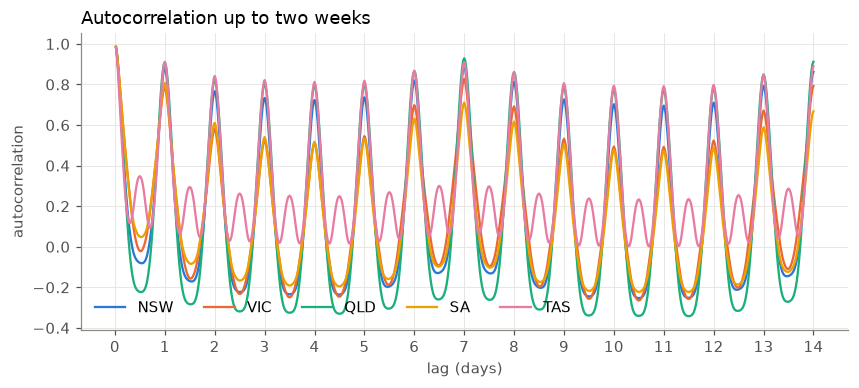

,NSW,VIC,QLD,SA,TAS
1 step,0.985,0.983,0.986,0.985,0.981
1 day (48),0.882,0.789,0.910,0.807,0.912
1 week (336),0.890,0.828,0.929,0.711,0.910
1 year (17520),0.747,0.636,0.784,0.567,0.785


In [8]:
def acf(x, lags):
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:-lag], x[lag:]) / denom for lag in lags])


lags = np.arange(1, 2 * STEPS_PER_WEEK + 1)
fig, ax = plt.subplots(figsize=(9, 3.5))
for state in STATES:
    ax.plot(lags / STEPS_PER_DAY, acf(train[state].to_numpy(), lags), color=COLORS[state], label=state)
ax.set_xlabel("lag (days)")
ax.set_ylabel("autocorrelation")
ax.set_xticks(range(15))
ax.legend(ncols=5, frameon=False, loc="lower left")
ax.set_title("Autocorrelation up to two weeks", loc="left")
save(fig, "acf")
plt.show()

key_lags = {"1 step": 1, "1 day (48)": 48, "1 week (336)": 336, "1 year (17520)": 17_520}
pd.DataFrame(
    {state: acf(train[state].to_numpy(), list(key_lags.values())) for state in STATES},
    index=list(key_lags),
).round(3)

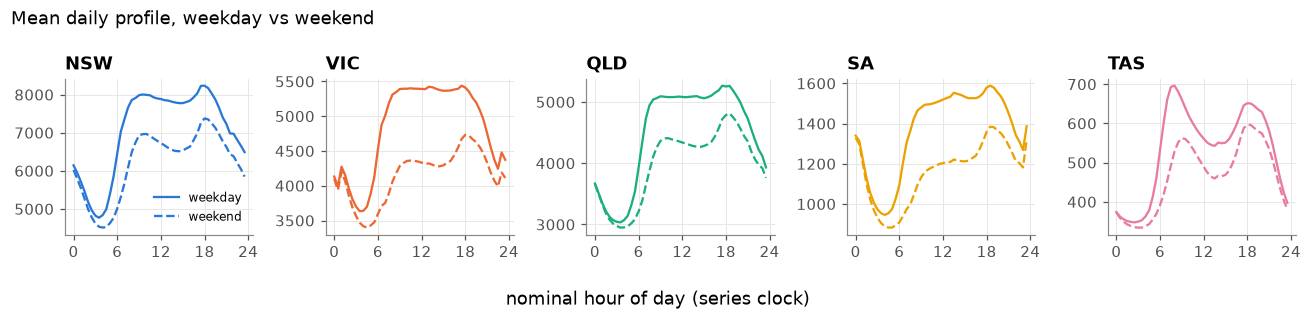

In [9]:
slot_hours = np.arange(STEPS_PER_DAY) / 2
weekday = nominal_time.dayofweek < 5
fig, axes = plt.subplots(1, len(STATES), figsize=(12, 2.8), sharex=True)
for ax, state in zip(axes, STATES):
    by_slot = train[state].groupby([weekday, train.index % STEPS_PER_DAY]).mean()
    ax.plot(slot_hours, by_slot[True], color=COLORS[state], label="weekday")
    ax.plot(slot_hours, by_slot[False], color=COLORS[state], linestyle="--", label="weekend")
    ax.set_title(state, loc="left", fontweight="bold")
    ax.set_xticks([0, 6, 12, 18, 24])
axes[0].legend(frameon=False, fontsize=8)
fig.supxlabel("nominal hour of day (series clock)")
fig.suptitle("Mean daily profile, weekday vs weekend", x=0.01, ha="left")
fig.tight_layout()
save(fig, "daily_profile")
plt.show()

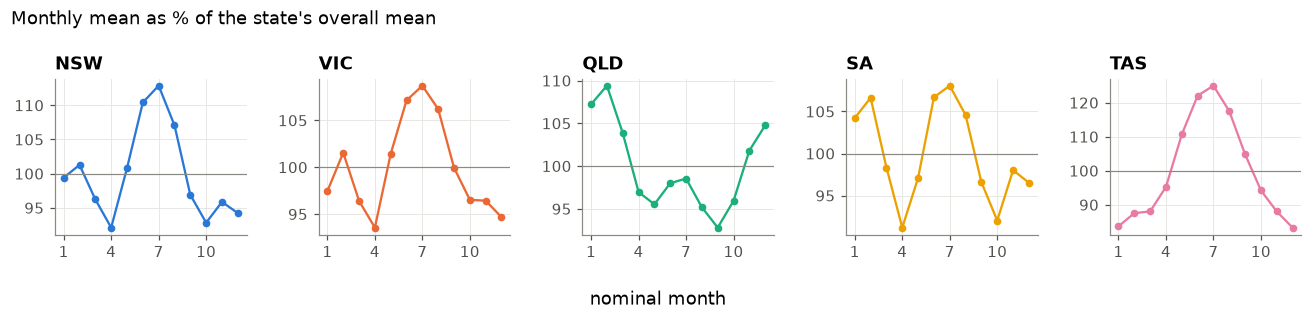

In [10]:
month = nominal_time.month
fig, axes = plt.subplots(1, len(STATES), figsize=(12, 2.8), sharex=True)
for ax, state in zip(axes, STATES):
    monthly = train[state].groupby(month).mean()
    ax.plot(monthly.index, monthly / monthly.mean() * 100, color=COLORS[state], marker="o", markersize=4)
    ax.axhline(100, color="#8a8984", linewidth=0.8)
    ax.set_title(state, loc="left", fontweight="bold")
    ax.set_xticks([1, 4, 7, 10])
fig.supxlabel("nominal month")
fig.suptitle("Monthly mean as % of the state's overall mean", x=0.01, ha="left")
fig.tight_layout()
save(fig, "monthly_profile")
plt.show()

All five series have strong daily and weekly cycles, with lower demand at weekends. The
weekly lag (336) correlates more strongly than the daily lag (48) in NSW, VIC and QLD,
about the same in TAS, and less in SA (0.71 against 0.81). The annual cycle depends on
the state. NSW, VIC and TAS peak in winter and QLD in summer, while SA has a summer peak
and a winter peak of similar size.

## 5. Negative values in Tasmania

The dataset card reports 22 negative values in TAS. All of them are in the training
block, within 17 nominal days of March 2005.

,first,last,count,minimum
nominal day,,,,
1155,2005-03-01 00:00:00,2005-03-01 10:30:00,17,-233.9
1169,2005-03-15 13:30:00,2005-03-15 13:30:00,1,-35.1
1171,2005-03-17 09:00:00,2005-03-17 10:30:00,4,-51.8


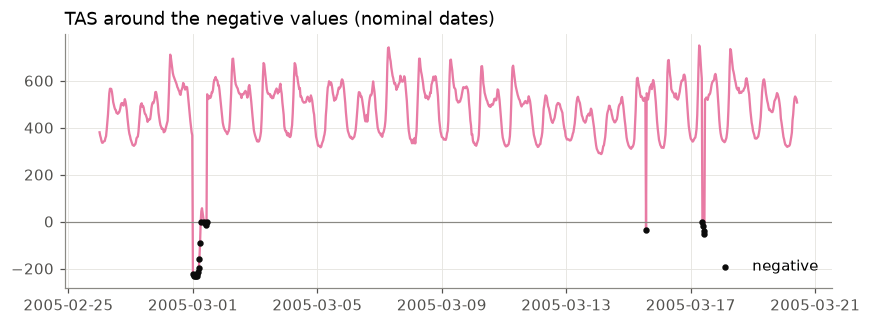

In [11]:
tas = train["TAS"]
negative = tas[tas < 0]
episodes = pd.DataFrame({
    "position": negative.index,
    "nominal day": negative.index // STEPS_PER_DAY,
    "nominal time": nominal_time[negative.index],
    "value": negative.round(1).to_numpy(),
})
display(episodes.groupby("nominal day").agg(
    first=("nominal time", "min"), last=("nominal time", "max"),
    count=("value", "size"), minimum=("value", "min")))

fig, ax = plt.subplots(figsize=(9, 3))
window = slice(episodes["position"].min() - 3 * STEPS_PER_DAY, episodes["position"].max() + 3 * STEPS_PER_DAY)
ax.plot(nominal_time[window], tas[window], color=COLORS["TAS"])
ax.scatter(episodes["nominal time"], episodes["value"], color="#0b0b0b", s=10, zorder=3, label="negative")
ax.axhline(0, color="#8a8984", linewidth=0.8)
ax.legend(frameon=False)
ax.set_title("TAS around the negative values (nominal dates)", loc="left")
save(fig, "tas_negative")
plt.show()

They are not scattered noise. Seventeen come from one episode on the first of those
days, between nominal 00:00 and 10:30, when the series drops to -234 and then recovers.
The other five fall on two days about two weeks later.

The upstream files explain the sign. The series is operational demand minus industrial
load, and on these days the total operational demand falls while the industrial load
stays near its usual level. The table below shows the main episode.

In [12]:
tas_up = upstream["TAS"].assign(total=lambda d: d["OperationalLessIndustrial"] + d["Industrial"])
window = tas_up[(tas_up["day"] >= "2005-02-28") & (tas_up["day"] <= "2005-03-01")]
window.set_index(["day", "Period"]).iloc[40:76:3][["total", "Industrial", "OperationalLessIndustrial"]].round(1)

total  Industrial  OperationalLessIndustrial
day        Period                                               
2005-02-28 41      1198.0       648.7                      549.3
           44      1114.0       653.2                      460.8
           47      1035.0       653.7                      381.3
2005-03-01 2        422.0       648.3                     -226.3
           5        411.0       643.3                     -232.3
           8        415.0       639.8                     -224.8
           11       480.0       638.5                     -158.5
           14       683.0       638.4                       44.6
           17       651.0       633.4                       17.6
           20       633.0       630.5                        2.5
           23      1169.0       626.7                      542.3
           26      1143.0       607.5                      535.5

Total operational demand in TAS drops from about 1,035 to about 410 for roughly 11 hours
and then returns to about 1,170, while the industrial load stays near 640. The negative
values are the difference of the two, not negative consumption. The files do not say
whether the drop in total demand was a real system event or a recording error. We follow
the card: keep the values, flag them, and avoid percentage errors for TAS.

## 6. Does the series clock follow daylight saving time?

NSW, VIC, SA and TAS observe daylight saving time (DST); Queensland does not. If the
series used local civil time, transition days would have 46 or 50 half-hours. If it used
a fixed standard-time clock, daily routines would move by one hour in the series clock
at each transition, and only in the DST states.

The test looks at the morning ramp: the first slot between nominal 04:00 and 12:00 where
demand passes the midpoint between the early-morning minimum and the late-morning
maximum. For each official transition, it compares the mean ramp slot on weekdays in the
10 days after with the 10 days before. The dates follow the rules in force at the time.
Until 2007, DST ended on the last Sunday of March and started on the last Sunday of
October (the first Sunday of October in TAS). From 2008 it ended on the first Sunday of
April and started on the first Sunday of October. In 2006 it ended a week later because
of the Commonwealth Games. As a placebo, the same shift is measured on random dates,
where no transition happens.

In [13]:
def morning_ramp(values):
    days = values[: n_days * STEPS_PER_DAY].reshape(n_days, STEPS_PER_DAY)
    threshold = (days[:, 8:16].min(axis=1) + days[:, 14:24].max(axis=1)) / 2
    above = days[:, 8:24] >= threshold[:, None]
    ramp = np.where(above.any(axis=1), 8 + above.argmax(axis=1), np.nan)
    return pd.Series(ramp, index=nominal_days)


def last_sunday(year, month):
    d = pd.Timestamp(year, month, 1) + pd.offsets.MonthEnd(0)
    return d - pd.Timedelta(days=(d.dayofweek + 1) % 7)


def first_sunday(year, month):
    d = pd.Timestamp(year, month, 1)
    return d + pd.Timedelta(days=(6 - d.dayofweek) % 7)


def transitions(state):
    out = []
    for year in range(2002, 2014):
        if year == 2006:
            end = first_sunday(2006, 4)  # Commonwealth Games extension
        else:
            end = last_sunday(year, 3) if year <= 2007 else first_sunday(year, 4)
        if year <= 2007:
            start = first_sunday(year, 10) if state == "TAS" else last_sunday(year, 10)
        else:
            start = first_sunday(year, 10)
        out += [("DST ends", end), ("DST starts", start)]
    return out


def shift(ramp, date, days=10):
    before = ramp[date - pd.Timedelta(days=days) : date - pd.Timedelta(days=1)]
    after = ramp[date + pd.Timedelta(days=1) : date + pd.Timedelta(days=days)]
    return after[after.index.dayofweek < 5].mean() - before[before.index.dayofweek < 5].mean()


ramps = {state: morning_ramp(train[state].to_numpy()) for state in STATES}
last_day = nominal_days[-1] - pd.Timedelta(days=10)
rows = []
for state in STATES:
    # QLD has no DST: use the NSW dates as a control.
    for kind, date in transitions("NSW" if state == "QLD" else state):
        if date <= last_day:
            rows.append({"state": state, "transition": kind, "date": date.date(),
                         "shift (steps)": shift(ramps[state], date)})
shifts = pd.DataFrame(rows)

rng = np.random.default_rng(0)
placebo_dates = pd.DatetimeIndex(rng.choice(nominal_days[15:-15], 300))
placebo = {state: np.nanstd([shift(ramps[state], d) for d in placebo_dates]) for state in STATES}

table = shifts.pivot_table(index="state", columns="transition", values="shift (steps)", aggfunc="mean")
table["transitions"] = shifts.groupby("state").size()
table["placebo SD"] = pd.Series(placebo)
table.loc[STATES].round(2)

transition,DST ends,DST starts,transitions,placebo SD
state,,,,
NSW,1.68,-1.48,22,0.65
VIC,1.83,-1.66,22,0.77
QLD,0.20,-0.16,22,0.37
SA,2.25,-1.87,22,0.86
TAS,1.53,-1.81,22,0.58


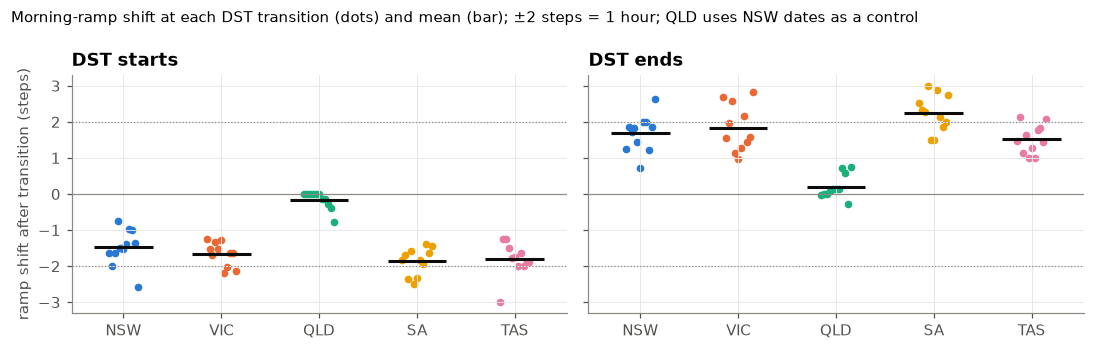

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, kind in zip(axes, ["DST starts", "DST ends"]):
    subset = shifts[shifts["transition"] == kind]
    for i, state in enumerate(STATES):
        values = subset.loc[subset["state"] == state, "shift (steps)"]
        jitter = np.linspace(-0.15, 0.15, len(values))
        ax.scatter(np.full(len(values), i) + jitter, values, color=COLORS[state], s=16)
        ax.hlines(values.mean(), i - 0.3, i + 0.3, color="#0b0b0b", linewidth=2)
    ax.axhline(0, color="#8a8984", linewidth=0.8)
    for level in (-2, 2):
        ax.axhline(level, color="#8a8984", linewidth=0.8, linestyle=":")
    ax.set_xticks(range(len(STATES)), STATES)
    ax.set_title(kind, loc="left", fontweight="bold")
axes[0].set_ylabel("ramp shift after transition (steps)")
fig.suptitle("Morning-ramp shift at each DST transition (dots) and mean (bar); "
             "±2 steps = 1 hour; QLD uses NSW dates as a control", x=0.01, ha="left", fontsize=10)
fig.tight_layout()
save(fig, "dst_ramp_shift")
plt.show()

In NSW, VIC, SA and TAS the mean shift is 1.5-2.3 steps, close to the 2 steps of one
hour. The ramp comes earlier in the series clock when DST starts and later when it ends,
and every single transition in these states moves in that direction. The mean shifts are
two to three times the placebo standard deviation. QLD, which has no DST, moves by about
0.2 steps. TAS matches its own pre-2008 start dates, which were earlier than the
mainland ones.

We read this as evidence that the series uses a fixed clock without daylight saving.
Every day then has 48 steps, and there are no duplicate or missing civil hours to
handle. It also suggests that positions run without gaps from 2002-01-01 00:00 in that
clock, because the shifts line up with the official dates for 11 years.

The upstream files agree: every day has 48 periods (section 1.1), which matches the 48
settlement periods per day of the national electricity market (NEM). The NEM runs on
Australian Eastern Standard Time (UTC+10) all year, and the `tsibbledata` documentation
of its Victorian subset, [`vic_elec`](https://tsibbledata.tidyverts.org/reference/vic_elec.html),
states that period 1 starts at midnight Eastern Standard Time. SA's later ramp fits its
local time, half an hour behind the NEM clock. Issue #6 should record this as analysis
evidence plus a secondary source, since AEMO's own documentation of these files has not
been found.

## 7. Correlation between states

In [15]:
train.corr().round(2)

,NSW,VIC,QLD,SA,TAS
NSW,1.00,0.86,0.82,0.79,0.76
VIC,0.86,1.00,0.73,0.86,0.71
QLD,0.82,0.73,1.00,0.68,0.54
SA,0.79,0.86,0.68,1.00,0.54
TAS,0.76,0.71,0.54,0.54,1.00


The states move together. The strongest correlations are between neighbouring mainland
regions (NSW-VIC and VIC-SA, 0.86) and the weakest are TAS with QLD and with SA (0.54).
The first comparison uses univariate forecasts, so this only matters for later
multivariate or cross-state ideas.

## 8. Seasonal naive reference on the training block

The MASE proposal divides each state's error by the in-sample MAE of the lag-336 naive
forecast on the training block. The table gives those denominators next to the lag-48
(previous day) naive MAE.

In [16]:
def naive_mae(x, lag):
    return np.mean(np.abs(x[lag:] - x[:-lag]))


naive = pd.DataFrame({
    "MAE lag 336 (MASE scale)": {s: naive_mae(train[s].to_numpy(), 336) for s in STATES},
    "MAE lag 48": {s: naive_mae(train[s].to_numpy(), 48) for s in STATES},
})
naive["lag 48 / lag 336"] = naive["MAE lag 48"] / naive["MAE lag 336 (MASE scale)"]
naive.round(3)

,MAE lag 336 (MASE scale),MAE lag 48,lag 48 / lag 336
NSW,417.737,446.469,1.069
VIC,294.599,348.849,1.184
QLD,215.200,242.248,1.126
SA,130.462,118.638,0.909
TAS,45.654,41.880,0.917


Lag 336 is the better naive forecast for NSW, VIC and QLD, but the previous day gives a
lower in-sample error for SA and TAS. These are one-step, in-sample errors on training
data, not 48-step forecasts from evaluation origins. They justify comparing both naive
variants on validation before fixing the comparator. On their own, they do not justify
changing the proposal.

### 8.1 Published Chronos results on this dataset

The Chronos paper ([Ansari et al., TMLR 2024](https://arxiv.org/abs/2403.07815)) lists
Australian Electricity under *zero-shot evaluation* in its Table 3: the dataset was not
used to train any Chronos model and is evaluated on the final 48 observations of each
series. Its footnote 5 notes that the authors did not check that zero-shot datasets start
after the end of the training data, and judge that risk minimal.

| Model (paper, final 48 steps) | MASE (Table 10) | WQL (Table 9) |
| --- | ---: | ---: |
| Chronos-T5 (Small), zero-shot | 1.399 | 0.074 |
| Seasonal naive | 1.253 | 0.084 |

On this dataset, zero-shot Chronos-T5 (Small) has a higher point error than the seasonal
naive forecast and a lower probabilistic error. The paper's seasonal naive uses the
default season length for 30-minute data in GluonTS, which is 48 steps, not 336. Its
evaluation is one window per series, five forecasts in total, so these numbers are noisy
and not comparable with our 365 origins per state. The paper also reports that
fine-tuning Chronos-T5 (Small) on each zero-shot dataset (learning rate 0.001, decayed
linearly to 0 over 1,000 steps) improves its aggregate score; it does not give the
Australian Electricity result separately.

## 9. Split boundaries and the validation block

The proposal splits the common 230,736-step prefix into training `[0, 195696)`,
validation `[195696, 213216)` and test `[213216, 230736)`. This section converts those
positions to nominal dates and counts forecast origins. Then it compares the validation
block with the last training year.

In [17]:
VAL_END = 213_216
BLOCKS = {"train": (0, TRAIN_END), "validation": (TRAIN_END, VAL_END), "test": (VAL_END, COMMON_LENGTH)}


def nominal(position):
    return NOMINAL_START + pd.Timedelta(minutes=30 * int(position))


blocks = pd.DataFrame({
    name: {
        "positions": f"[{start:,}, {end:,})",
        "first step (nominal)": nominal(start),
        "last step (nominal)": nominal(end - 1),
        "days": (end - start) / STEPS_PER_DAY,
        "origins per state (every 48 steps)": (end - start) // STEPS_PER_DAY if name != "train" else None,
    }
    for name, (start, end) in BLOCKS.items()
}).T
display(blocks)

extra = pd.DataFrame({
    state: {
        "extra steps": str(len(raw[state]) - COMMON_LENGTH),
        "first extra step (nominal)": nominal(COMMON_LENGTH) if len(raw[state]) > COMMON_LENGTH else None,
        "last extra step (nominal)": nominal(len(raw[state]) - 1)
        if len(raw[state]) > COMMON_LENGTH else None,
    }
    for state in STATES
}).T
extra

,positions,first step (nominal),last step (nominal),days,origins per state (every 48 steps)
train,"[0, 195,696)",2002-01-01 00:00:00,2013-02-28 23:30:00,4077.0,None
validation,"[195,696, 213,216)",2013-03-01 00:00:00,2014-02-28 23:30:00,365.0,365
test,"[213,216, 230,736)",2014-03-01 00:00:00,2015-02-28 23:30:00,365.0,365


,extra steps,first extra step (nominal),last extra step (nominal)
NSW,0,NaN,NaN
VIC,0,NaN,NaN
QLD,1536,2015-03-01 00:00:00,2015-04-01 23:30:00
SA,48,2015-03-01 00:00:00,2015-03-01 23:30:00
TAS,0,NaN,NaN


In [18]:
origins = (VAL_END - TRAIN_END) // STEPS_PER_DAY
print(f"validation: {origins} origins x {len(STATES)} states = {origins * len(STATES):,} forecasts; "
      f"with 20 Chronos samples each: {origins * len(STATES) * 20:,} sampled trajectories of 48 steps")
print("test has the same count.")

validation: 365 origins x 5 states = 1,825 forecasts; with 20 Chronos samples each: 36,500 sampled trajectories of 48 steps
test has the same count.


In [19]:
validation = pd.DataFrame({state: raw[state][TRAIN_END:VAL_END] for state in STATES})
validation.index = pd.RangeIndex(TRAIN_END, VAL_END, name="position")
last_train_year = train.iloc[-(VAL_END - TRAIN_END):]

comparison = pd.DataFrame({
    "last train year mean": last_train_year.mean(),
    "validation mean": validation.mean(),
    "last train year max": last_train_year.max(),
    "validation max": validation.max(),
    "train max": train.max(),
    "validation min": validation.min(),
    "validation negatives": (validation < 0).sum(),
    "validation steps above train max": (validation > train.max()).sum(),
})
comparison["mean change %"] = (comparison["validation mean"] / comparison["last train year mean"] - 1) * 100
comparison.round(1)

,last train year mean,validation mean,last train year max,validation max,train max,validation min,validation negatives,validation steps above train max,mean change %
NSW,6565.2,6336.1,12285.5,10420.0,12865.8,3719.3,0,0,-3.5
VIC,4716.0,4656.8,8443.4,9345.0,9494.0,2905.1,0,0,-1.3
QLD,4274.0,4105.6,6972.0,6948.8,7514.4,2580.7,0,0,-3.9
SA,1259.7,1211.6,2756.0,2937.1,3182.5,652.3,0,0,-3.8
TAS,478.0,480.6,957.6,945.4,1093.5,235.2,0,0,0.5


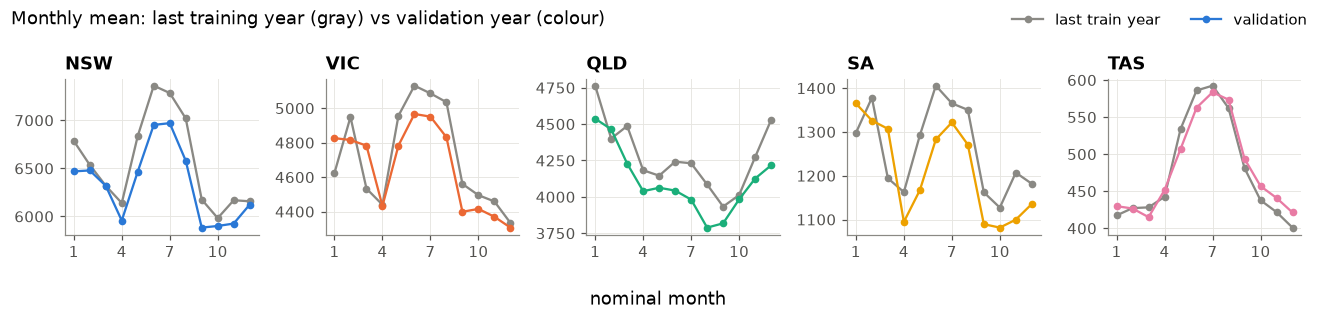

In [20]:
val_month = (NOMINAL_START + pd.to_timedelta(validation.index * 30, unit="min")).month
last_month = nominal_time[-(VAL_END - TRAIN_END):].month
fig, axes = plt.subplots(1, len(STATES), figsize=(12, 2.8), sharex=True)
for ax, state in zip(axes, STATES):
    before = last_train_year[state].groupby(last_month).mean()
    after = validation[state].groupby(val_month).mean()
    ax.plot(before.index, before, color="#8a8984", marker="o", markersize=4, label="last train year")
    ax.plot(after.index, after, color=COLORS[state], marker="o", markersize=4, label="validation")
    ax.set_title(state, loc="left", fontweight="bold")
    ax.set_xticks([1, 4, 7, 10])
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, ncols=2, loc="upper right")
fig.supxlabel("nominal month")
fig.suptitle("Monthly mean: last training year (gray) vs validation year (colour)", x=0.01, ha="left")
fig.tight_layout()
save(fig, "validation_vs_last_train_year")
plt.show()

Both held-out blocks cover one full nominal year starting in March: validation runs from
2013-03-01 to 2014-02-28 and test from 2014-03-01 to 2015-02-28. Each contains every
season, one Easter and one Christmas-New Year period. The extra QLD and SA observations
all come after the test block (up to 2015-04-01), so dropping them leaves training and
validation intact and creates no gaps.

A held-out block has 365 origins per state, 1,825 forecasts in total. At 20 Chronos
samples per forecast, one evaluation pass means 36,500 sampled 48-step trajectories per
block.

In validation, the decline from section 3 carries on. Mean demand is 1-4% below the last
training year in the mainland states and about the same in TAS (+0.5%). The monthly
shape is similar. Most of the drop is in winter in NSW, VIC and SA, while in QLD it is
spread over most of the year. No validation value is above the training maximum or below
zero. Validation looks like more of the recent training years, not a new regime, and for
fine-tuning the most recent training years are the closest in level.

## 10. Calendar effects and anomalous days

A lag-336 seasonal naive forecast made at a daily origin predicts the next 48 steps from
the same steps a week earlier, all of them observed at the origin. Its error for each
day, divided by the state's MASE scale from section 8, measures how different the day is
from the same day a week before. We use it to find the days that will be hard for any
forecaster. This section uses the training block only.

The holiday list has the national fixed-date holidays (New Year's Day, Australia Day,
Anzac Day, Christmas Day and Boxing Day) plus Good Friday and Easter Monday, on their
actual dates. It leaves out substitute weekdays and state-specific holidays.

In [21]:
def easter_sunday(year):
    # Anonymous Gregorian algorithm
    a, b, c = year % 19, year // 100, year % 100
    d, e = b // 4, b % 4
    g = (8 * b + 13) // 25
    h = (19 * a + b - d - g + 15) % 30
    i, k = c // 4, c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    month = (h + l - 7 * m + 114) // 31
    day = (h + l - 7 * m + 114) % 31 + 1
    return pd.Timestamp(year, month, day)


holidays = {}
for y in range(2002, 2014):
    easter = easter_sunday(y)
    holidays.update({
        pd.Timestamp(y, 1, 1): "New Year's Day", pd.Timestamp(y, 1, 26): "Australia Day",
        easter - pd.Timedelta(days=2): "Good Friday", easter + pd.Timedelta(days=1): "Easter Monday",
        pd.Timestamp(y, 4, 25): "Anzac Day", pd.Timestamp(y, 12, 25): "Christmas Day",
        pd.Timestamp(y, 12, 26): "Boxing Day",
    })
holidays = pd.Series(holidays).sort_index()
holidays = holidays[holidays.index <= nominal_days[-1]]

day_values = {s: train[s].to_numpy()[: n_days * STEPS_PER_DAY].reshape(n_days, STEPS_PER_DAY) for s in STATES}
scale = naive["MAE lag 336 (MASE scale)"]
daily_error = pd.DataFrame({
    s: np.r_[np.full(7, np.nan), np.abs(day_values[s][7:] - day_values[s][:-7]).mean(axis=1)] / scale[s]
    for s in STATES
}, index=nominal_days)

is_holiday = daily_error.index.isin(holidays.index)
after_holiday = daily_error.index.isin(holidays.index + pd.Timedelta(days=7))
xmas = ((daily_error.index.month == 12) & (daily_error.index.day >= 20)) | (
    (daily_error.index.month == 1) & (daily_error.index.day <= 7))
day_type = np.select(
    [is_holiday, after_holiday, xmas],
    ["holiday", "week after a holiday", "other days 20 Dec-7 Jan"],
    default="normal day",
)
error_by_type = daily_error.groupby(day_type).mean()
error_by_type["days"] = pd.Series(day_type).value_counts()
error_by_type.loc[["normal day", "holiday", "week after a holiday", "other days 20 Dec-7 Jan"]].round(2)

,NSW,VIC,QLD,SA,TAS,days
normal day,0.92,0.90,0.90,0.91,0.99,3762
holiday,2.53,2.75,3.04,2.30,1.65,78
week after a holiday,2.39,2.51,2.60,2.10,1.45,66
other days 20 Dec-7 Jan,1.65,1.81,1.76,1.93,0.84,171


In [22]:
daily_mean_values = pd.DataFrame({s: day_values[s].mean(axis=1) for s in STATES}, index=nominal_days)
excluded = set(holidays.index) | set(daily_mean_values.index[xmas])


def reference_level(date):
    same_weekday = [date + pd.Timedelta(weeks=w) for w in (-3, -2, -1, 1, 2, 3)]
    usable = [d for d in same_weekday if d in daily_mean_values.index and d not in excluded]
    return daily_mean_values.loc[usable].median()


holiday_effect = pd.DataFrame(
    [(daily_mean_values.loc[d] / reference_level(d) - 1) * 100 for d in holidays.index],
    index=holidays.index,
)
holiday_effect["holiday"] = holidays
holiday_effect.groupby("holiday")[STATES].mean().loc[
    ["New Year's Day", "Australia Day", "Good Friday", "Easter Monday", "Anzac Day",
     "Christmas Day", "Boxing Day"]
].round(1)  # % change vs median of same weekday +-1..3 weeks (non-holiday)

,NSW,VIC,QLD,SA,TAS
holiday,,,,,
New Year's Day,-9.6,-13.8,-14.9,-8.8,-12.8
Australia Day,-3.7,-5.2,-7.1,-0.3,-6.7
Good Friday,-17.3,-21.4,-16.3,-21.9,-13.0
Easter Monday,-16.5,-18.2,-15.1,-19.8,-14.4
Anzac Day,-11.9,-12.1,-10.6,-15.0,-10.1
Christmas Day,-19.7,-21.1,-19.2,-21.2,-22.5
Boxing Day,-20.5,-19.4,-17.6,-21.9,-21.8


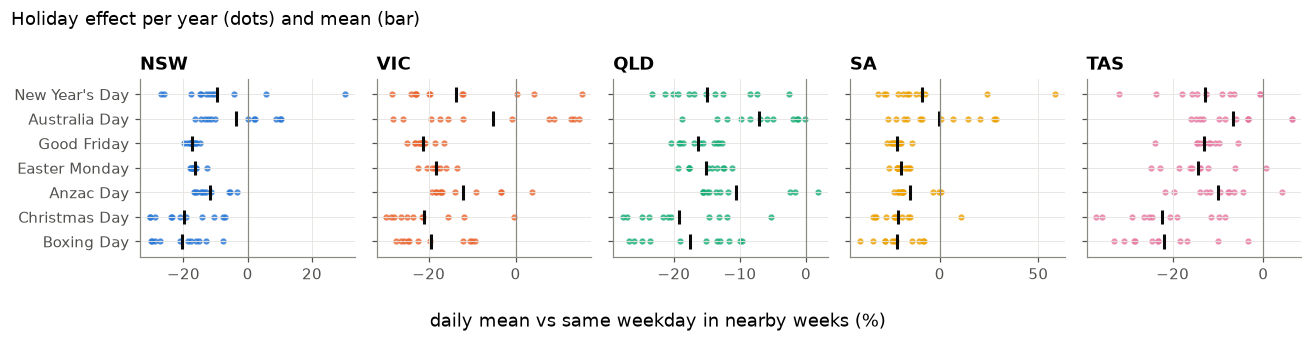

In [23]:
order = ["New Year's Day", "Australia Day", "Good Friday", "Easter Monday", "Anzac Day",
         "Christmas Day", "Boxing Day"]
fig, axes = plt.subplots(1, len(STATES), figsize=(12, 3), sharey=True)
for ax, state in zip(axes, STATES):
    for i, name in enumerate(order):
        values = holiday_effect.loc[holiday_effect["holiday"] == name, state]
        ax.scatter(values, np.full(len(values), i), color=COLORS[state], s=10, alpha=0.7)
        ax.vlines(values.mean(), i - 0.3, i + 0.3, color="#0b0b0b", linewidth=2)
    ax.axvline(0, color="#8a8984", linewidth=0.8)
    ax.set_title(state, loc="left", fontweight="bold")
axes[0].set_yticks(range(len(order)), order)
axes[0].invert_yaxis()
fig.supxlabel("daily mean vs same weekday in nearby weeks (%)")
fig.suptitle("Holiday effect per year (dots) and mean (bar)", x=0.01, ha="left")
fig.tight_layout()
save(fig, "holiday_effect")
plt.show()

In [24]:
top = (
    daily_error.stack().rename("scaled error").reset_index()
    .rename(columns={"level_0": "nominal date", "level_1": "state"})
    .nlargest(15, "scaled error")
)
top["weekday"] = top["nominal date"].dt.day_name()
top["holiday"] = top["nominal date"].map(holidays).fillna("")
top["daily max"] = [day_values[s][nominal_days.get_loc(d)].max() for s, d in zip(top["state"], top["nominal date"])]
top["max a week earlier"] = [
    day_values[s][nominal_days.get_loc(d) - 7].max() for s, d in zip(top["state"], top["nominal date"])
]
top.round({"scaled error": 2, "daily max": 1, "max a week earlier": 1})

,nominal date,state,scaled error,weekday,holiday,daily max,max a week earlier
14698,2010-01-18,SA,8.93,Monday,,1489.3,3117.6
11356,2008-03-21,VIC,8.67,Friday,Good Friday,4078.4,8347.2
20057,2012-12-25,QLD,8.56,Tuesday,Christmas Day,4209.9,6822.4
14663,2010-01-11,SA,8.48,Monday,,3117.6,1742.8
11358,2008-03-21,SA,8.40,Friday,Good Friday,1232.4,2791.3
12928,2009-01-29,SA,8.38,Thursday,,3182.5,1923.3
11373,2008-03-24,SA,8.35,Monday,Easter Monday,1224.1,2917.5
16623,2011-02-07,SA,8.20,Monday,,1532.8,3098.0
18302,2012-01-09,QLD,8.18,Monday,,7256.8,4633.4
12933,2009-01-30,SA,8.13,Friday,,3094.4,1726.0


In [25]:
share = {}
for s in STATES:
    e = daily_error[s].dropna().sort_values(ascending=False)
    share[s] = e.iloc[: int(len(e) * 0.05)].sum() / e.sum() * 100
pd.Series(share, name="% of total naive error from the worst 5% of days").round(1)

NSW    17.8
VIC    20.5
QLD    19.3
SA     24.0
TAS    14.4
Name: % of total naive error from the worst 5% of days, dtype: float64

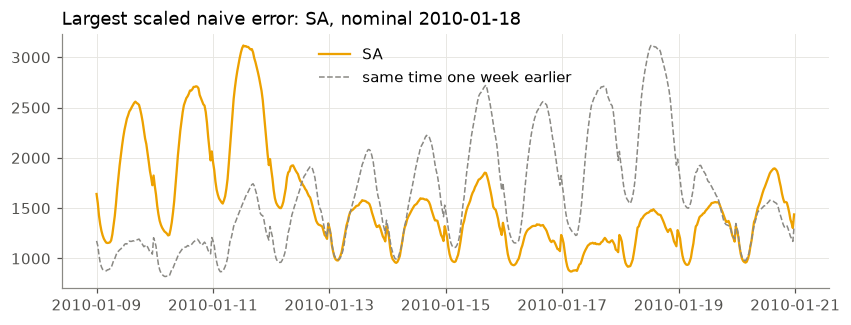

In [26]:
state, date = top.iloc[0]["state"], top.iloc[0]["nominal date"]
start = (nominal_days.get_loc(date) - 9) * STEPS_PER_DAY
end = (nominal_days.get_loc(date) + 3) * STEPS_PER_DAY
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(nominal_time[start:end], train[state].iloc[start:end], color=COLORS[state], label=state)
ax.plot(nominal_time[start:end], train[state].iloc[start - STEPS_PER_WEEK : end - STEPS_PER_WEEK].to_numpy(),
        color="#8a8984", linewidth=1, linestyle="--", label="same time one week earlier")
ax.legend(frameon=False)
ax.set_title(f"Largest scaled naive error: {state}, nominal {date.date()}", loc="left")
save(fig, "largest_anomaly")
plt.show()

Holidays cut demand. On Christmas Day, Boxing Day, Good Friday and Easter Monday it is
roughly 13-23% below the same weekday in nearby weeks, and on New Year's Day and Anzac
Day 9-15% below. Australia Day has a smaller effect that varies more from year to year.
Part of that spread comes from holidays that fall on a weekend: they are compared with
other weekends, and the substitute weekday is not flagged.

The naive forecast struggles on these days. In the mainland states its scaled error on
holidays is about 2.3-3.0 times the normal-day level (1.7 times in TAS). The error stays
high on the same weekday a week later (2.1-2.6 times), when the naive forecast copies
the holiday. The rest of the period from 20 December to 7 January is also harder, at
about 1.7-1.9 times normal, except in TAS.

The worst days are holidays and a few summer days in SA, VIC and QLD whose peaks are far
above the same day a week earlier: SA on 2009-01-29 and 2010-01-11, VIC on 2010-01-11
and 2013-01-04, and QLD on 2012-01-09. Several more come a week after one of these
events, when the naive forecast repeats the peak; the figure shows SA on 2010-01-18. The
January dates fit heatwaves, but the dataset has no temperature to check. The worst 5%
of days account for 14-24% of the total naive error, and SA has the largest share.

Each held-out block contains these events once, and they affect every method. An average
error can hide them, so the evaluation should also report errors on holidays and on the
worst origins. A univariate model cannot see these days coming from past demand. Holiday
flags are known in advance, so they can be added later as a feature without leakage.
Temperature would need forecast values, not observed ones, to be realistic.

## 11. Findings and open questions

| Topic | Finding | Suggested follow-up |
| --- | --- | --- |
| Record order | `T1 NSW, T2 VIC, T3 QUN, T4 SA, T5 TAS`. The DVC files match the card's counts and ranges. | Keep the card check when the loader changes. |
| Source | The series equal AEMO `OperationalLessIndustrial` in the `tsibbledata` raw files (commit `58ea724`), up to `float32` rounding. Unit not stated; most likely MW. | Update the dataset card (#6). Consider `float64` storage in the DVC loader. |
| Clock | Morning ramps shift by about one hour at DST transitions in the DST states only, and the upstream files have 48 periods on every day. Both fit the NEM clock (UTC+10, no DST). | Record in #6 as evidence and secondary source. |
| TAS negatives | 22 values on three days in March 2005, down to -234. Total operational demand fell while the subtracted industrial load stayed near 640. | Keep and flag them. Avoid percentage errors for TAS. |
| Scale | Levels differ by more than 10x between states. | Supports a scaled cross-state metric (MASE). |
| Level drift | All states peak in years 7-9 and then decline, by up to about 10%. | Watch for level mismatch between early training years and the validation and test years. |
| Seasonality | Strong daily and weekly cycles. NSW, VIC and TAS peak in winter, QLD in summer, SA in both. | A 512-step context (about 10.7 days) covers the weekly cycle but not the annual one. |
| Split dates | Validation is nominal 2013-03-01 to 2014-02-28 and test is 2014-03-01 to 2015-02-28. Each covers one full year with one Easter and one Christmas. | Supports the proposed 365-day blocks. |
| Extra QLD and SA steps | All lie after the test block (to 2015-04-01). | Dropping them affects neither training nor validation. |
| Validation level | 1-4% below the last training year in mainland states. No values beyond the training range and no negatives. | The decline continues. Recent training years are the most representative. |
| Holidays | Demand is 9-23% lower on the main holidays. Naive error is 2-3 times normal on holidays and a week after them. | Report holiday errors separately. Consider holiday flags as a later feature. |
| Extreme days | The worst days are holidays and summer peaks. The worst 5% of days give 14-24% of the naive error. | Include a worst-origins analysis in the evaluation. |
| Naive comparator | Lag 336 is best in-sample for NSW, VIC and QLD. Lag 48 is best for SA and TAS. | Compare both on validation before fixing the comparator (#5). |
| Published Chronos result | Zero-shot dataset in the Chronos paper. On its final 48 steps, Chronos-T5 (Small) has MASE 1.399 against 1.253 for a lag-48 seasonal naive, and WQL 0.074 against 0.084. | Cite in the model card. Treat a naive win on MASE as a plausible outcome. |

Not checked here: the test block, AEMO's own documentation of the unit and clock, the
cause of the TAS drop, state-specific and substitute holidays, and temperature data for
the extreme days.